# Model discrepancy with a Gaussian process

A structurally wrong model leaves correlated residuals.  A Gaussian-process
term in the covariance absorbs them (Kennedy and O'Hagan's discrepancy), the
model parameters relax toward their true values, and the total predictive
band bends where the model cannot.  First on a toy, then on a differential
cross section whose potential is missing a piece of physics.  For contrast,
the same defect is also fit with an explicitly sampled mean correction.

Recipes: 7, 8, 36

In [1]:
import corner
import dynesty
import emcee
import jitr
import matplotlib.pyplot as plt
import numpy as np
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from numpy.polynomial import legendre as L
from scipy import stats
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

## A linear model and a non-linear truth

Thirty points of a gently curving function, fit by a line.  No line can
follow it, so the residuals of the best line are smooth and correlated.

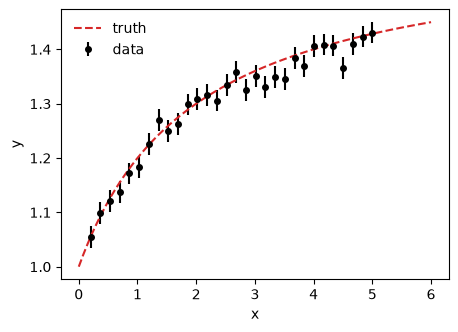

In [2]:
def truth(x):
    return (0.8 * x + 1.0) / (1.0 + x / 2.0)


rng = np.random.default_rng(7)
x = np.linspace(0.2, 5.0, 30)
noise = 0.02
data = rx.Dataset(
    x, truth(x) + rng.normal(0.0, noise, x.size), np.full(x.size, noise), label="toy"
)
x_fine = np.linspace(0.0, 6.0, 80)

m = rx.Parameter("m", prior=stats.norm(0.0, 2.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(0.0, 2.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp = rx.Comparison(data, line)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=4, color="k", label="data")
ax.plot(x_fine, truth(x_fine), "--", color="C3", label="truth")
ax.set(xlabel="x", ylabel="y")
ax.legend(frameon=False)
plt.show()

## The GP discrepancy as a covariance term

`T.kernel` wraps any scikit-learn kernel.  One `Parameter` is derived per
free hyperparameter, sampled in sklearn's log-theta space; here they are
passed explicitly with priors.  Two references: the line with its reported
statistics only, and the line with an uncorrelated model error
(`T.model_error`), which can widen the diagonal but cannot describe a smooth
defect.

In [3]:
kernel = ConstantKernel(1.0) * Matern(length_scale=2.0, nu=2.5) + WhiteKernel(
    1e-6, "fixed"
)
log_amp2 = rx.Parameter("log_A2", prior=stats.norm(-4.0, 2.0), latex=r"\log A^2")
log_ell = rx.Parameter("log_ell", prior=stats.norm(0.5, 1.0), latex=r"\log \ell")
gp = T.kernel(kernel, params=[log_amp2, log_ell])
gamma = rx.Parameter(
    "log_gamma", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\gamma"
)

p_stat = rx.Problem([rx.Constraint([comp])])
p_diag = rx.Problem(
    [rx.Constraint([comp], terms=[T.model_error(gamma, averaging=True)])]
)
p_gp = rx.Problem([rx.Constraint([comp], terms=[gp])])
print("GP problem columns:", p_gp.names)


def fit(problem, seed, start=None, n_walkers=24, n_steps=3000):
    # emcee from the prior, or from a small ball around ``start``
    rng = np.random.default_rng(seed)
    if start is None:
        p0 = problem.sample_prior(n_walkers, rng=rng)
    else:
        p0 = np.asarray(start) + 1e-2 * rng.standard_normal((n_walkers, problem.ndim))
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(p0, n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


s_stat = fit(p_stat, 1)
line_fit = np.median(s_stat, axis=0)  # a starting point for the nuisance problems
s_diag = fit(p_diag, 2, start=[*line_fit, np.log(0.05)])
s_gp = fit(p_gp, 3, start=[*line_fit, -4.0, 0.5])

GP problem columns: ['m', 'b', 'log_A2', 'log_ell']


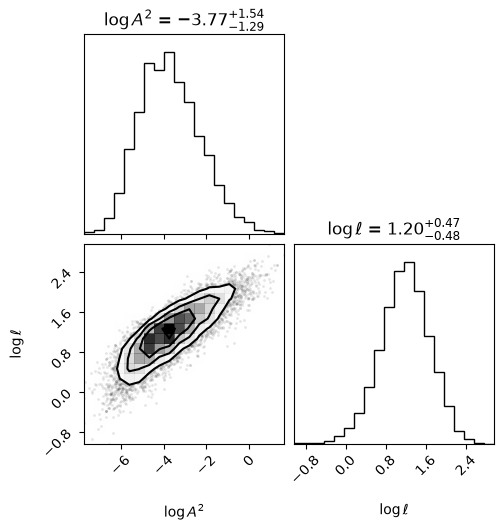

In [4]:
fig = corner.corner(
    s_gp[:, p_gp.columns([log_amp2, log_ell])],
    labels=[r"$\log A^2$", r"$\log \ell$"],
    show_titles=True,
)
plt.show()

## Propagating the total uncertainty

The line's own band (its parameters only) cannot bend.  `total_predictive_band`
conditions the GP on the residuals at each posterior row, predicts the
discrepancy on the plotting grid, and adds it: everything the problem
declared is propagated, and nothing has to be told which columns are the
kernel's.

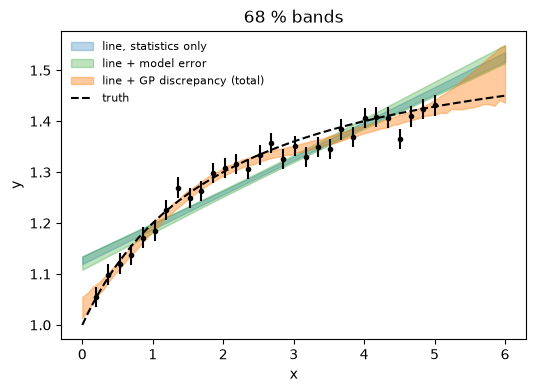

In [5]:
def mean_band(problem, samples, levels=(16, 84)):
    on_fine = line.bind(x_fine, {})
    cols = problem.columns(line.params)
    return rx.predictive.predictive_band(
        [on_fine(*s[cols]) for s in samples[::10]], levels=levels
    )


band_gp = rx.predictive.total_predictive_band(
    p_gp, gp, line.bind(x_fine, {}), x_fine, s_gp, rng=4
)
fig, ax = plt.subplots(figsize=(6, 4))
for label, (p, s), color in (
    ("line, statistics only", (p_stat, s_stat), "C0"),
    ("line + model error", (p_diag, s_diag), "C2"),
):
    lo, hi = mean_band(p, s)
    ax.fill_between(x_fine, lo, hi, color=color, alpha=0.3, label=label)
ax.fill_between(
    x_fine, *band_gp, color="C1", alpha=0.4, label="line + GP discrepancy (total)"
)
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=3, color="k")
ax.set(xlabel="x", ylabel="y", title="68 % bands")
ax.legend(frameon=False, fontsize=8)
plt.show()

## What the GP captured

Condition the GP on the residuals of the posterior-mean line and compare
with the true defect, `truth(x) − line(x)`.

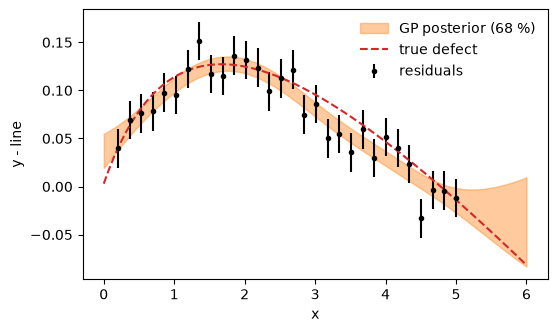

In [6]:
theta_gp = np.median(s_gp, axis=0)
resid = data.y - line.bind(x, {})(*theta_gp[p_gp.columns(line.params)])
mean_d, cov_d = rx.predictive.gp_posterior_predictive(
    kernel,
    theta_gp[p_gp.columns([log_amp2, log_ell])],
    x,
    resid,
    x_fine,
    train_noise_var=noise**2,
)
sd_d = np.sqrt(np.clip(np.diag(cov_d), 0, None))
true_defect = truth(x_fine) - line.bind(x_fine, {})(
    *theta_gp[p_gp.columns(line.params)]
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.errorbar(x, resid, noise, fmt="o", ms=3, color="k", label="residuals")
ax.fill_between(
    x_fine,
    mean_d - sd_d,
    mean_d + sd_d,
    color="C1",
    alpha=0.4,
    label="GP posterior (68 %)",
)
ax.plot(x_fine, true_defect, "--", color="C3", label="true defect")
ax.set(xlabel="x", ylabel="y - line")
ax.legend(frameon=False)
plt.show()

## For contrast: a sampled mean correction (recipes 8, 36)

The discrepancy can instead be a *mean* correction with sampled
coefficients: `line + rx.Model(delta, phi)` on a Legendre basis.  It removes
the bias too, but its band is only the coefficients' uncertainty, and it
says nothing outside the data.  A GP is the same idea with the coefficients
integrated out and a smoothness prior instead of a basis choice.

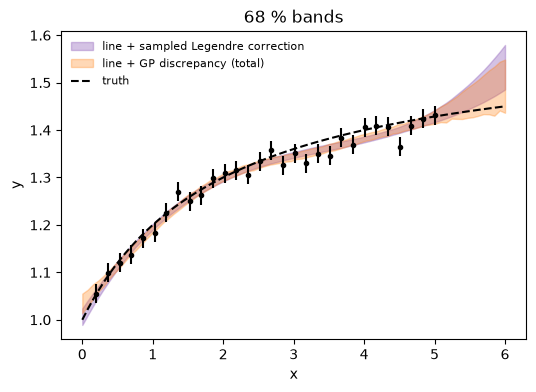

line only          m = 0.066 +/- 0.003   b = 1.127 +/- 0.008
line + GP          m = 0.093 +/- 0.047   b = 0.942 +/- 0.295
line + correction  m = 0.082 +/- 0.163   b = 1.016 +/- 0.668


In [7]:
phis = [
    rx.Parameter(f"phi_{k}", prior=stats.norm(0.0, 0.5), latex=rf"\phi_{k}")
    for k in range(4)
]


def delta(x, *phi):
    return L.legval(np.asarray(x, dtype=float) / 3.0 - 1.0, phi)


corrected = line + rx.Model(delta, phis)
p_mean = rx.Problem([rx.Constraint([rx.Comparison(data, corrected)])])
s_mean = fit(p_mean, 5, start=[*line_fit, 0.0, 0.0, 0.0, 0.0])
on_fine = corrected.bind(x_fine, {})
lo, hi = rx.predictive.predictive_band(
    [on_fine(*s[p_mean.columns(corrected.params)]) for s in s_mean[::10]],
    levels=(16, 84),
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(
    x_fine, lo, hi, color="C4", alpha=0.4, label="line + sampled Legendre correction"
)
ax.fill_between(
    x_fine, *band_gp, color="C1", alpha=0.3, label="line + GP discrepancy (total)"
)
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=3, color="k")
ax.set(xlabel="x", ylabel="y", title="68 % bands")
ax.legend(frameon=False, fontsize=8)
plt.show()
for name, p, s in (
    ("line only", p_stat, s_stat),
    ("line + GP", p_gp, s_gp),
    ("line + correction", p_mean, s_mean),
):
    cols = p.columns(line.params)
    print(
        f"{name:18s} m = {s[:, cols[0]].mean():.3f} +/- {s[:, cols[0]].std():.3f}   b = {s[:, cols[1]].mean():.3f} +/- {s[:, cols[1]].std():.3f}"
    )

## A differential cross section with missing physics

Mock n + ⁴⁰Ca elastic scattering at 14.1 MeV generated from a potential with
volume *and* surface absorption, fit with a potential that has only volume
absorption.  Reaction models are driven by dynesty: affine-invariant
ensembles mix poorly on optical-model posteriors.  The comparison is in log
space, so the GP describes a fractional defect in angle.

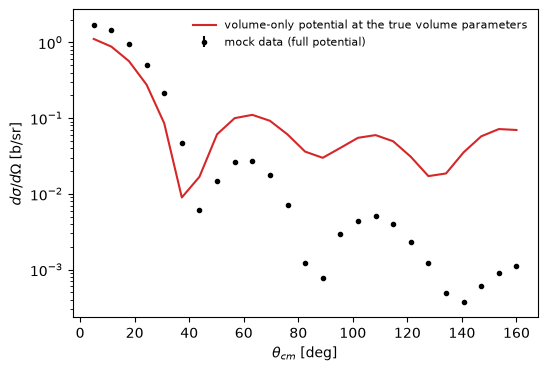

In [8]:
reaction = jitr.reactions.ElasticReaction(target=(40, 20), projectile=(1, 0))
E_lab = 14.1
R40 = 40 ** (1 / 3)
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def full_central(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) - 1j * Wd * (
        -4 * ad
    ) * woods_saxon_prime_safe(r, Rd, ad)


def volume_central(r, Vv, Wv, Rv, av):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av)


def spin_orbit(r, Vso, Rso, aso):
    return Vso * mso**2 * thomas_safe(r, Rso, aso)


so_args = (6.0, 1.1 * R40, 0.45)
full_truth = np.array([48.0, 3.5, 1.1 * R40, 0.7, 21.0, 1.2 * R40, 0.5])
volume_truth = full_truth[:4]

full_params = [
    rx.Parameter(n, prior=stats.norm(0, 1))
    for n in ("Vv", "Wv", "Rv", "av", "Wd", "Rd", "ad")
]
omp_full = rx.reactions.ElasticXS(
    "dXS/dA",
    full_central,
    spin_orbit,
    lambda ws, *x: (tuple(x), so_args),
    full_params,
    lmax=10,
)
volume_params = [
    rx.Parameter("Vv", prior=stats.norm(48.0, 8.0), latex="V_v"),
    rx.Parameter("Wv", prior=stats.norm(4.0, 4.0), bounds=(0.0, 30.0), latex="W_v"),
    rx.Parameter("Rv", prior=stats.norm(1.15 * R40, 0.2), latex="R_v"),
    rx.Parameter("av", prior=stats.norm(0.65, 0.1), bounds=(0.3, 1.2), latex="a_v"),
]
omp_vol = rx.reactions.ElasticXS(
    "dXS/dA",
    volume_central,
    spin_orbit,
    lambda ws, *x: (tuple(x), so_args),
    volume_params,
    lmax=10,
)

angles = np.deg2rad(np.linspace(5.0, 160.0, 25))
meta = {"reaction": reaction, "Elab": E_lab}
y_full = omp_full.bind(angles, meta)(*full_truth)
y_xs = y_full * (1 + rng.normal(0.0, 0.04, angles.size))
d_xs = rx.Dataset(angles, y_xs, 0.04 * y_xs, label="n+40Ca 14.1 MeV", meta=meta)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    np.rad2deg(angles),
    d_xs.y,
    d_xs.y_err,
    fmt="o",
    ms=3,
    color="k",
    label="mock data (full potential)",
)
ax.plot(
    np.rad2deg(angles),
    omp_vol.bind(angles, meta)(*volume_truth),
    color="C3",
    label="volume-only potential at the true volume parameters",
)
ax.set(xlabel=r"$\theta_{cm}$ [deg]", ylabel=r"$d\sigma/d\Omega$ [b/sr]", yscale="log")
ax.legend(frameon=False, fontsize=8)
plt.show()

In [9]:
comp_xs = rx.Comparison(d_xs, omp_vol, space=tf.log)
xs_amp = rx.Parameter("log_A2_xs", prior=stats.norm(-4.0, 2.0), latex=r"\log A^2")
xs_ell = rx.Parameter("log_ell_xs", prior=stats.norm(-0.5, 1.0), latex=r"\log \ell")
gp_xs = T.kernel(
    ConstantKernel(0.1**2) * Matern(0.5, nu=2.5) + WhiteKernel(1e-6, "fixed"),
    params=[xs_amp, xs_ell],
)
p_xs_bare = rx.Problem([rx.Constraint([comp_xs])])
p_xs_gp = rx.Problem([rx.Constraint([comp_xs], terms=[gp_xs])])


def nested(problem, seed, nlive=150):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=0.5, print_progress=False)
    res = sampler.results
    print(
        f"log Z = {res.logz[-1]:.2f} +/- {res.logzerr[-1]:.2f}, {int(np.sum(res.ncall))} likelihood calls"
    )
    return res.samples_equal(rstate=np.random.default_rng(seed))


s_xs_bare = nested(p_xs_bare, 10)
s_xs_gp = nested(p_xs_gp, 11)

log Z = -649.52 +/- 0.65, 88099 likelihood calls


log Z = -17.48 +/- 0.53, 64665 likelihood calls


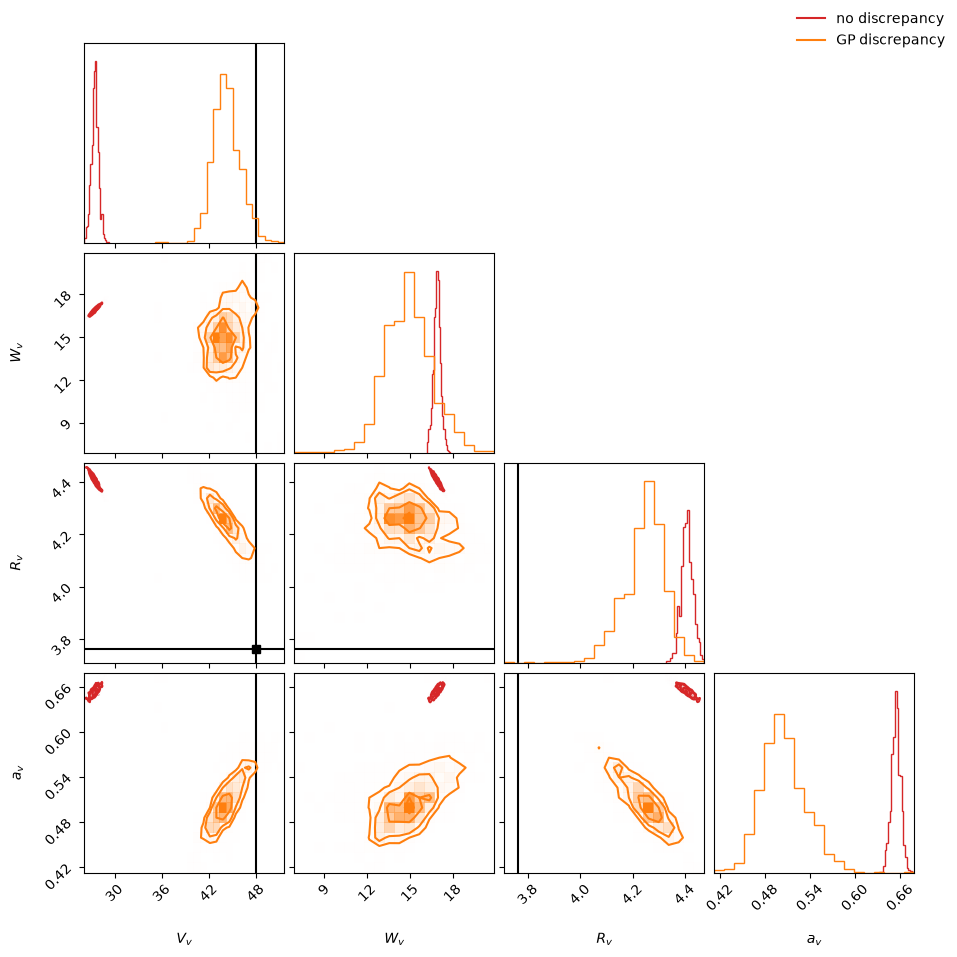

In [10]:
labels = [f"${p.latex}$" for p in volume_params]
fig = corner.corner(
    s_xs_bare[:, p_xs_bare.columns(volume_params)],
    color="C3",
    labels=labels,
    truths=volume_truth,
    truth_color="k",
    plot_datapoints=False,
)
corner.corner(
    s_xs_gp[:, p_xs_gp.columns(volume_params)],
    fig=fig,
    color="C1",
    plot_datapoints=False,
)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C3", label="no discrepancy"),
        plt.Line2D([], [], color="C1", label="GP discrepancy"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()

## The learned discrepancy against the missing physics

The defect the GP has to describe is the log ratio of the data-generating
full potential to the fitted volume-only one; it is drawn here at the
posterior-median volume parameters, on a fine grid, so the question is
whether the GP interpolates it smoothly between the data and how it relaxes
outside them.

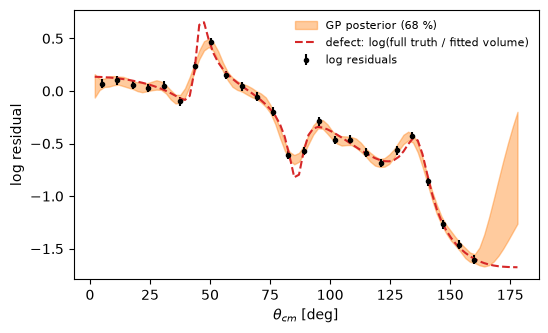

In [11]:
theta_xs = np.median(s_xs_gp, axis=0)
fine = np.deg2rad(np.linspace(2.0, 178.0, 90))
resid_xs = comp_xs.y - comp_xs.predict(*theta_xs[p_xs_gp.columns(volume_params)])
mean_d, cov_d = rx.predictive.gp_posterior_predictive(
    gp_xs.kernel,
    theta_xs[p_xs_gp.columns([xs_amp, xs_ell])],
    angles,
    resid_xs,
    fine,
    train_noise_var=comp_xs.y_err**2,
)
sd_d = np.sqrt(np.clip(np.diag(cov_d), 0, None))
true_defect = np.log(omp_full.bind(fine, meta)(*full_truth)) - np.log(
    omp_vol.bind(fine, meta)(*theta_xs[p_xs_gp.columns(volume_params)])
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.errorbar(
    np.rad2deg(angles),
    resid_xs,
    comp_xs.y_err,
    fmt="o",
    ms=3,
    color="k",
    label="log residuals",
)
ax.fill_between(
    np.rad2deg(fine),
    mean_d - sd_d,
    mean_d + sd_d,
    color="C1",
    alpha=0.4,
    label="GP posterior (68 %)",
)
ax.plot(
    np.rad2deg(fine),
    true_defect,
    "--",
    color="C3",
    label="defect: log(full truth / fitted volume)",
)
ax.set(xlabel=r"$\theta_{cm}$ [deg]", ylabel="log residual")
ax.legend(frameon=False, fontsize=8)
plt.show()

## Takeaways

- A GP discrepancy is just another covariance term; `total_predictive_band`
  propagates it to any grid from the problem alone.
- Uncorrelated model error widens the diagonal; it cannot represent
  correlated mis-modelling.  The GP can, and the model parameters relax.
- A sampled mean correction removes bias too, but carries no honest width
  away from the data.
- On the cross section the GP recovers the missing surface absorption as a
  smooth function of angle and moves `V_v` toward its true value; `W_v` and
  `R_v` stay biased, because volume and surface absorption are degenerate
  at one energy and no discrepancy model restores information the data do
  not contain.